In [3]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


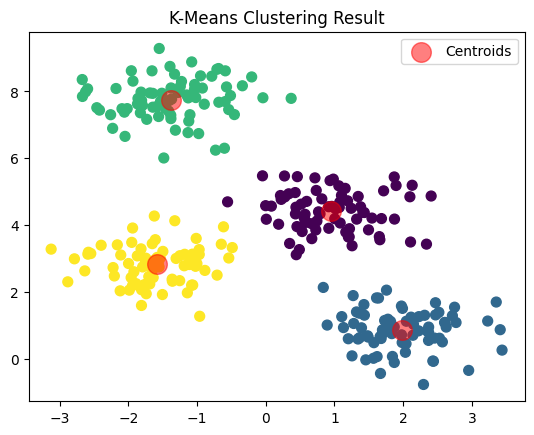

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate Synthetic Data
# We are creating 300 points clustered around 4 centers
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)  #change the random_state to see different clusters and centers to see different elbow plots

# 2. Implement K-Means
# HINT: Initialize the KMeans object with 4 clusters, then 'fit' it to X
kmeans = KMeans(n_clusters=4, random_state=0)#here randome state is used to ensure reproducibility of results. By setting random_state to a specific value, you can ensure that the same random numbers are generated each time you run the code, which can be helpful for debugging and comparing results.
kmeans.fit(X)

# 3. Get Predictions
#Use the .predict() method to assign each point to a cluster
labels = kmeans.predict(X)

# 4. Plotting (Provided)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5, label='Centroids')
plt.title("K-Means Clustering Result")
plt.legend()
plt.show()

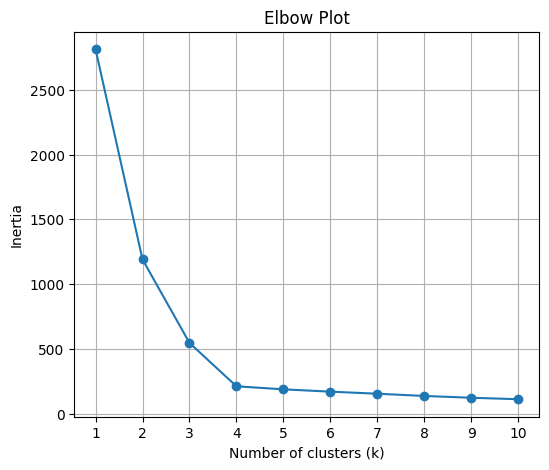

In [5]:
inertias = []
k_values = range(1, 11)
#It is the sum of squared distances of each point to its assigned cluster center (centroid).Inertia=∑(distance of point to its centroid)2 

for k in k_values:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Plot")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the Architecture
# HINT: Use models.Sequential() to create a stack of layers.
# We want: 
# - An input layer with 16 neurons (ReLU activation)
# - A hidden layer with 8 neurons (ReLU activation)
# - An output layer with 1 neuron (Sigmoid activation for binary classification)

model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)), 
    layers.Dense(8, activation='relu'),                     
    layers.Dense(1, activation='sigmoid')                   
])

# 2. Compile the Model
# HINT: The 'optimizer' is the algorithm that updates weights (like Adam).
# The 'loss' function measures how wrong the model is.
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)            

# 3. View the Architecture
# This shows how many "parameters" (weights) the model will learn.
model.summary()

print("If you see the model summary above, you've successfully built a Neural Network!")

C:\Users\ritan\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

If you see the model summary above, you've successfully built a Neural Network!


In [7]:
import torch
import torch.nn as nn

class ComplexNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=(64, 128, 64), output_dim=1):
        super().__init__()
        # HINT: nn.Sequential groups layers together.
        # Use nn.Linear(input, output) for dense layers.
        # Use nn.ReLU() for activation and nn.Dropout(p) for regularization.
        
        self.net = nn.Sequential(
            # Layer 1: Input to 64 neurons
            nn.Linear(input_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Layer 2: 64 to 128 neurons
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.BatchNorm1d(hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3: 128 to 64 neurons
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),

            # Output Layer:64 to output_dim
            nn.Linear(hidden_dims[2], output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        # HINT: This is where the data 'x' passes through the network
        return self.net(x)

# 1. Initialize the model
complex_model = ComplexNet()

# 2. Test with a small batch of data (first 16 points)
# HINT: Data must be converted to a Torch 'float32' Tensor
x_batch = torch.tensor(X[:16], dtype=torch.float32)
complex_output = complex_model(x_batch)

# 3. Check the results
print(complex_model)
print("Output shape (should be 16, 1):", complex_output.shape)

ComplexNet(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
    (11): Sigmoid()
  )
)
Output shape (should be 16, 1): torch.Size([16, 1])


Training the PyTorch Neural Network...
Epoch 0: Loss 0.7005
Epoch 10: Loss 0.5846
Epoch 20: Loss 0.3003
Epoch 30: Loss 0.0752
Epoch 40: Loss 0.0278

Final Training Accuracy: 99.25%


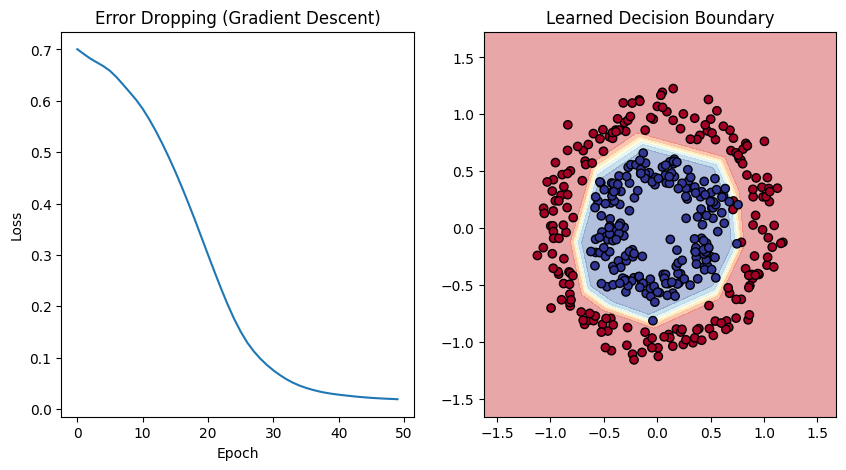

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles

# 1. Generate "Landing Zone" Data
X_circles, y_circles = make_circles(n_samples=400, noise=0.1, factor=0.5, random_state=40)

# Task: Convert NumPy arrays to PyTorch Tensors
# HINT: Use torch.tensor() and ensure the type is 'float32'
X_tensor = torch.tensor(X_circles, dtype=torch.float32)
y_tensor = torch.tensor(y_circles, dtype=torch.float32).unsqueeze(1) # We add a dimension for the loss function

# 2. Build the Neural Network
class CircleNet(nn.Module):
    def __init__(self):
        super().__init__()
        # HINT: Define a stack of layers: Linear(2->8) -> ReLU -> Linear(8->8) -> ReLU -> Linear(8->1) -> Sigmoid
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid() # Squishes output between 0 and 1 (probability)
        )
    def forward(self, x):
        return self.net(x)

torch_model = CircleNet()

# 3. Setup Optimizer and Loss Function
# HINT: Use Adam optimizer and Binary Cross Entropy Loss (BCELoss)
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.03)
criterion = nn.BCELoss()

# 4. The Training Loop (The "Learning" Part)
epochs = 50
losses = []

print("Training the PyTorch Neural Network...")
for epoch in range(epochs):
    torch_model.train()
    
    # STEP A: Reset the gradients to zero
    optimizer.zero_grad()
    
    # STEP B: Forward Pass (Predict)
    y_pred = torch_model(X_tensor)
    
    # STEP C: Calculate the Error (Loss)
    loss = criterion(y_pred, y_tensor)
    
    # STEP D: Backpropagation (Calculate how to change weights)
    loss.backward()
    
    # STEP E: Update Weights (Take a step)
    optimizer.step()
    
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

# 5. Evaluate Accuracy
with torch.no_grad():
    # HINT: If prediction >= 0.5, it's class 1, otherwise 0
    preds = (torch_model(X_tensor) >= 0.5).float()
    accuracy = (preds == y_tensor).float().mean()
    print(f"\nFinal Training Accuracy: {accuracy.item() * 100:.2f}%")

# 6. Visualization (Provided)
# This code will visualize the 'Safe Zone' your model has learned
torch_model.eval()
with torch.no_grad():
    x_min, x_max = X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5
    y_min, y_max = X_circles[:, 1].min() - 0.5, X_circles[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    Z = torch_model(grid).numpy().reshape(xx.shape)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Error Dropping (Gradient Descent)")
plt.xlabel("Epoch"); plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='RdYlBu', edgecolors='k')
plt.title("Learned Decision Boundary")
plt.show()

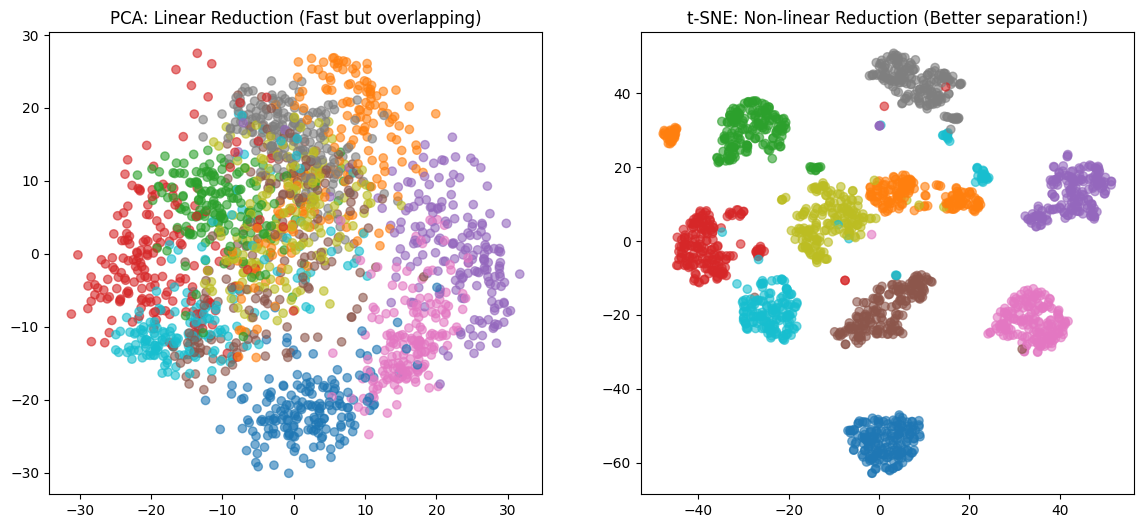

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Load Data (Handwritten digits: each image is 8x8 pixels = 64 dimensions)
digits = load_digits()
X, y = digits.data, digits.target

# 2. Apply PCA (Principal Component Analysis)
# HINT: Initialize PCA with 2 components and use fit_transform()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Apply t-SNE (t-Distributed Stochastic Neighbor Embedding)
# HINT: t-SNE is better at preserving local clusters. Use 2 components.
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# 4. Plotting the Comparison (Provided)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot PCA
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6)
ax1.set_title("PCA: Linear Reduction (Fast but overlapping)")

# Plot t-SNE
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.6)
ax2.set_title("t-SNE: Non-linear Reduction (Better separation!)")

plt.show()

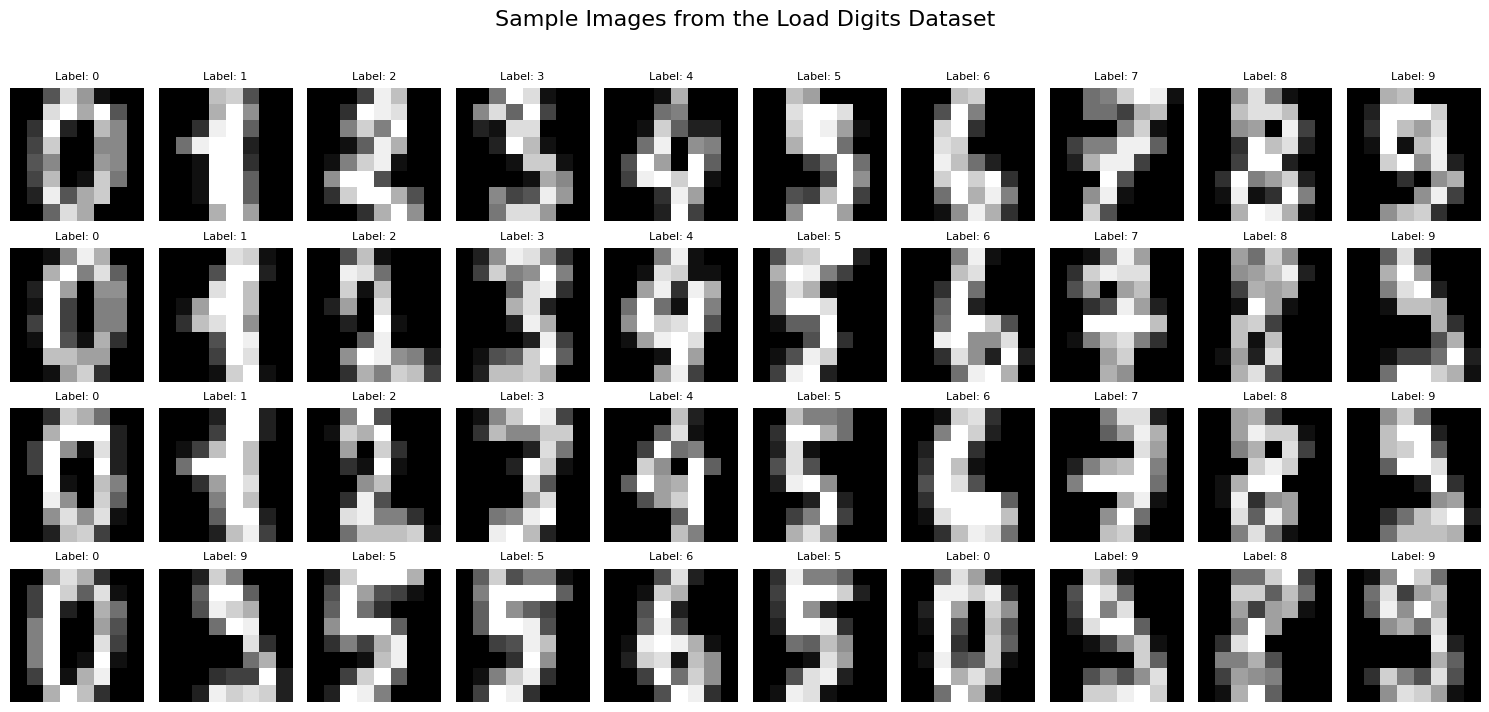

In [10]:
fig, axes = plt.subplots(4, 10, figsize=(15, 7))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}", fontsize=8)
    ax.axis('off')

plt.suptitle("Sample Images from the Load Digits Dataset", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

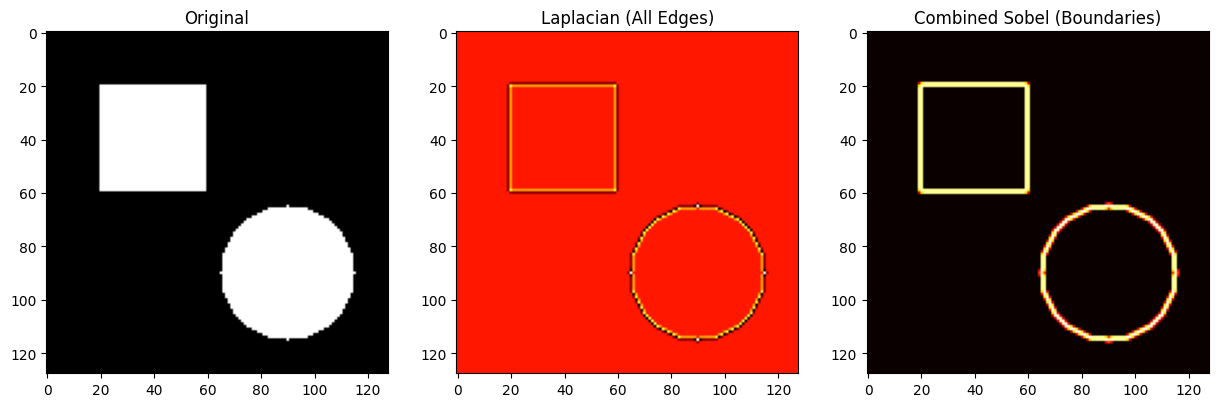

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 1. Image Preparation (Simplified)
# We create a synthetic 128x128 image with a square and a circle
img_array = np.zeros((128, 128), dtype=np.float32)
img_array[20:60, 20:60] = 1.0  # White square
rr, cc = np.ogrid[:128, :128]
circle_mask = (rr - 90)**2 + (cc - 90)**2 <= 25**2
img_array[circle_mask] = 1.0   # White circle

# Task: Convert the image to a PyTorch tensor with shape (Batch, Channel, H, W)
# HINT: A CNN expects 4 dimensions. Use .unsqueeze(0) twice.
image_tensor = torch.tensor(img_array).unsqueeze(0).unsqueeze(0)

# 2. Build the CNN Layer
# HINT: in_channels=1 (grayscale), out_channels=3 (3 different filters), kernel_size=3
edge_cnn = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=3, padding=1, bias=False)

# 3. Define the "Edge Detectors" (Kernels)
# Sobel-X detects vertical lines, Sobel-Y detects horizontal lines.
sobel_x = torch.tensor([[[-1., 0., 1.],
                         [-2., 0., 2.],
                         [-1., 0., 1.]]])

# TODO: Define Sobel-Y (the horizontal version of the matrix above)
sobel_y = torch.tensor([[[-1., -2., -1.],
                         [ 0.,  0.,  0.],
                         [ 1.,  2.,  1.]]])

laplacian = torch.tensor([[[ 0., -1.,  0.],
                            [-1.,  4., -1.],
                            [ 0., -1.,  0.]]])

# Task: Load these filters into the CNN's weights
edge_cnn.weight.data = torch.stack([sobel_x, sobel_y, laplacian], dim=0)

# 4. Forward Pass (The "Vision" Step)
with torch.no_grad():
    # HINT: Pass the image_tensor through the edge_cnn
    feature_maps = edge_cnn(image_tensor)

# 5. Calculate Edge Magnitude
# HINT: Combine vertical (map 0) and horizontal (map 1) edges using Pythagorean theorem: sqrt(x^2 + y^2)
sobel_x_out = feature_maps[0, 0].numpy()
sobel_y_out = feature_maps[0, 1].numpy()
sobel_mag = np.sqrt(sobel_x_out**2 + sobel_y_out**2)

# 6. Visualization (Provided)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_array, cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(feature_maps[0, 2].numpy(), cmap='hot'); axes[1].set_title("Laplacian (All Edges)")
axes[2].imshow(sobel_mag, cmap='hot'); axes[2].set_title("Combined Sobel (Boundaries)")
plt.show()

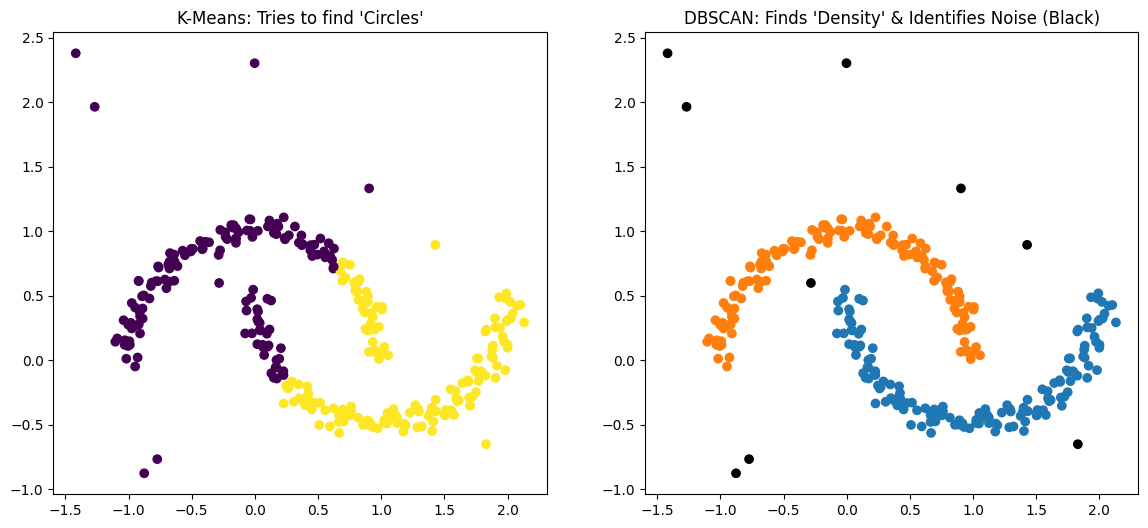

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN

# 1. Generate "Moon-shaped" data + random noise (Provided)
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
np.random.seed(42)
outliers = np.random.uniform(low=-1.5, high=2.5, size=(10, 2))
X = np.vstack([X, outliers]) # Merging the shapes with the noise

# 2. Implement K-Means
# HINT: Try to find 2 clusters. Does it work on curved data?
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# 3. Implement DBSCAN (Density-Based Spatial Clustering)
# HINT: This looks for "dense" areas. 
# Set eps (radius) to 0.2 and min_samples (minimum points to form a group) to 5.
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# 4. Plotting the Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot K-Means Results
ax1.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
ax1.set_title("K-Means: Tries to find 'Circles'")

# Plot DBSCAN Results
# HINT: DBSCAN labels noise as -1. We color them black.
colors = ['black' if label == -1 else plt.cm.tab10(label) for label in dbscan_labels]
ax2.scatter(X[:, 0], X[:, 1], c=colors)
ax2.set_title("DBSCAN: Finds 'Density' & Identifies Noise (Black)")

plt.show()